Total job postings: 20

Sample tokenized job:
  Machine Learning Engineer: ['build', 'and', 'deploy', 'machine', 'learning', 'models', 'using', 'python', 'tensorflow', 'deep', 'learning', 'neural', 'networks', 'data', 'pipelines']

Word2Vec vocabulary size: 183
Embedding dimension     : 100

WORD SIMILARITY EXPLORATION

Words most similar to 'python':
  modeling             similarity: 0.8927
  machine              similarity: 0.8855
  analyze              similarity: 0.8773
  learning             similarity: 0.8728
  predictive           similarity: 0.8695

Words most similar to 'deep':
  tensorflow           similarity: 0.9719
  reinforcement        similarity: 0.9691
  pytorch              similarity: 0.9641
  learning             similarity: 0.9634
  neural               similarity: 0.9611

Job embeddings matrix shape: (20, 100)

JOB RECOMMENDATION DEMO

Query: 'I know Python and want to work with neural networks and deep learning'
Rank  Job Title                           Similari

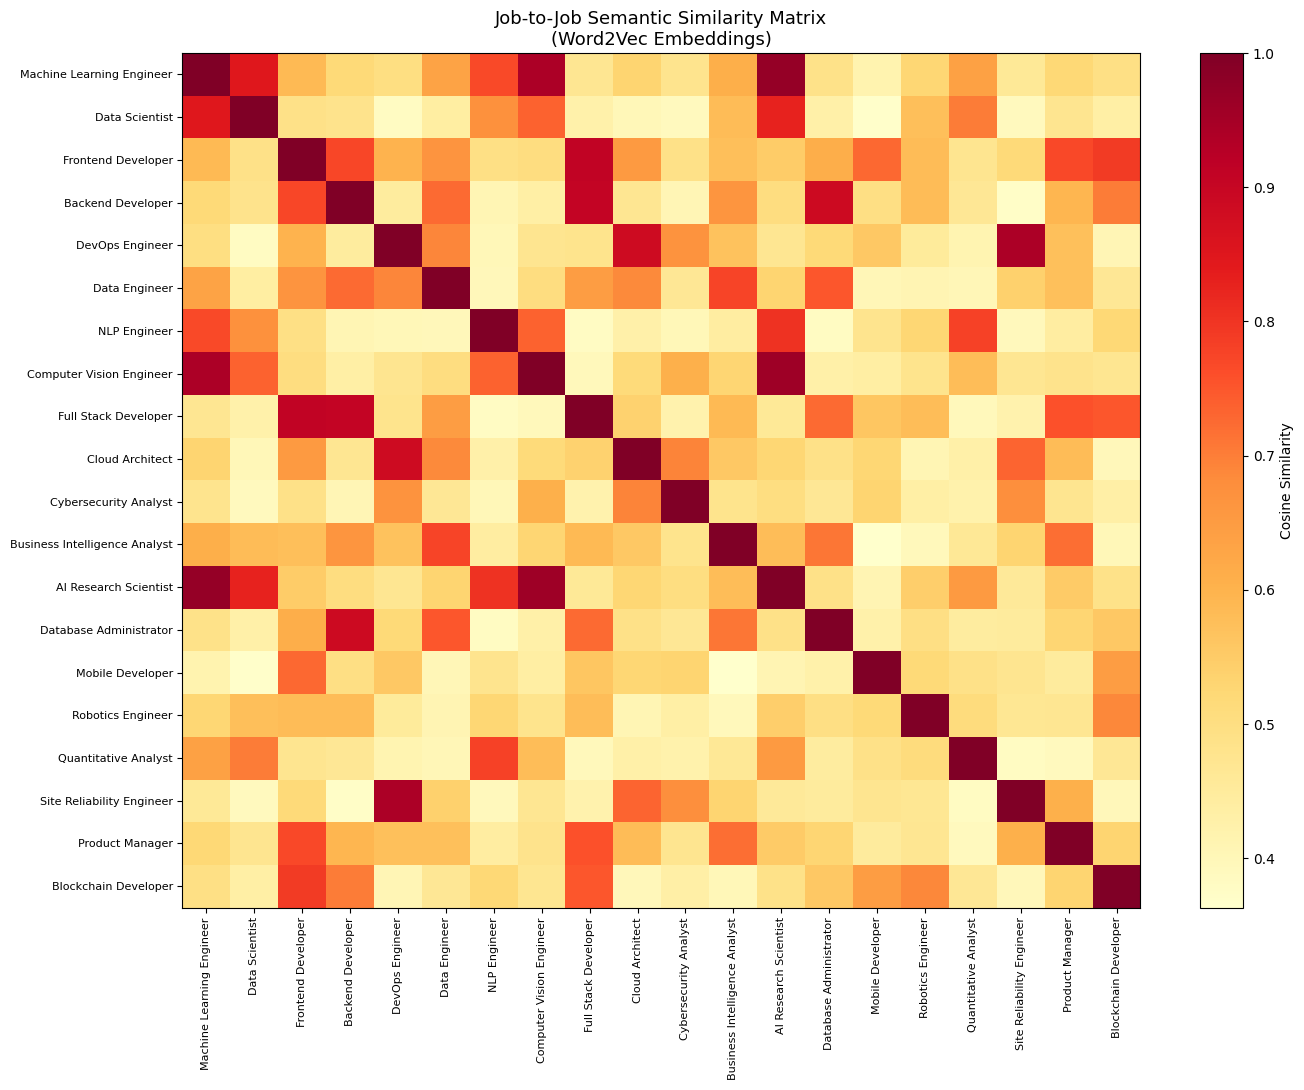


Saved: similarity_heatmap.png


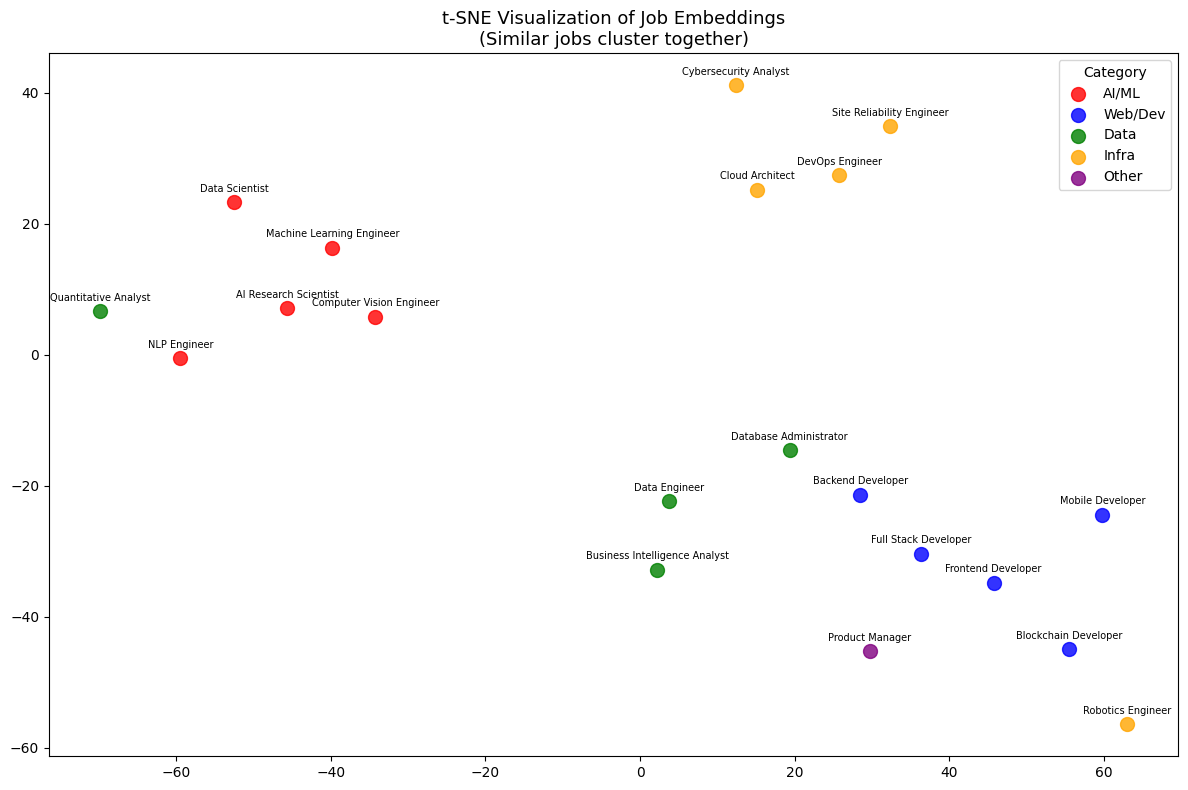

Saved: embeddings_tsne.png

WORD VECTOR ARITHMETIC

deep + javascript - python ≈
  interface            0.8954
  html                 0.8880
  css                  0.8831

     WORD EMBEDDINGS — SUMMARY
  Problem        : Semantic Job Recommendation
  Embedding      : Word2Vec (Skip-gram)
  Vector Size    : 100 dimensions
  Vocabulary     : 183 words
  Jobs Indexed   : 20
  Similarity     : Cosine Similarity
  Visualization  : t-SNE (100D → 2D)
  Outputs        : similarity_heatmap.png, embeddings_tsne.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings("ignore")


from gensim.models import Word2Vec
from gensim.utils import simple_preprocess


job_data = [
    {
        "title": "Machine Learning Engineer",
        "description": "Build and deploy machine learning models using Python TensorFlow deep learning neural networks data pipelines"
    },
    {
        "title": "Data Scientist",
        "description": "Analyze large datasets statistical modeling Python pandas numpy scikit-learn machine learning predictive analytics"
    },
    {
        "title": "Frontend Developer",
        "description": "Build responsive web applications using React JavaScript HTML CSS user interface design components"
    },
    {
        "title": "Backend Developer",
        "description": "Develop REST APIs server side applications Python Django Flask databases SQL PostgreSQL microservices"
    },
    {
        "title": "DevOps Engineer",
        "description": "Manage cloud infrastructure AWS Docker Kubernetes CI CD pipelines automation deployment monitoring"
    },
    {
        "title": "Data Engineer",
        "description": "Build data pipelines ETL processes Apache Spark Hadoop SQL databases cloud storage data warehousing"
    },
    {
        "title": "NLP Engineer",
        "description": "Natural language processing text classification sentiment analysis transformers BERT GPT Python deep learning"
    },
    {
        "title": "Computer Vision Engineer",
        "description": "Image recognition object detection convolutional neural networks OpenCV deep learning TensorFlow PyTorch"
    },
    {
        "title": "Full Stack Developer",
        "description": "React JavaScript Node backend frontend databases REST APIs web development agile team collaboration"
    },
    {
        "title": "Cloud Architect",
        "description": "Design cloud solutions AWS Azure GCP infrastructure scalability security networking serverless architecture"
    },
    {
        "title": "Cybersecurity Analyst",
        "description": "Network security threat detection penetration testing firewalls encryption vulnerability assessment incident response"
    },
    {
        "title": "Business Intelligence Analyst",
        "description": "Data visualization Tableau Power BI SQL reporting dashboards business analytics KPIs stakeholder communication"
    },
    {
        "title": "AI Research Scientist",
        "description": "Research deep learning reinforcement learning neural architecture search publications Python PyTorch optimization"
    },
    {
        "title": "Database Administrator",
        "description": "Manage SQL NoSQL databases MySQL PostgreSQL MongoDB performance tuning backup recovery query optimization"
    },
    {
        "title": "Mobile Developer",
        "description": "iOS Android mobile applications Swift Kotlin React Native Flutter UI UX app store deployment"
    },
    {
        "title": "Robotics Engineer",
        "description": "Robot programming ROS sensors actuators computer vision motion planning embedded systems C++ Python"
    },
    {
        "title": "Quantitative Analyst",
        "description": "Financial modeling statistics Python R risk analysis algorithmic trading time series forecasting mathematics"
    },
    {
        "title": "Site Reliability Engineer",
        "description": "System reliability monitoring logging Kubernetes Docker Linux scripting automation incident management uptime"
    },
    {
        "title": "Product Manager",
        "description": "Product roadmap user stories agile scrum stakeholder management market research prioritization team leadership"
    },
    {
        "title": "Blockchain Developer",
        "description": "Smart contracts Solidity Ethereum blockchain decentralized applications Web3 cryptography distributed systems"
    },
]

df = pd.DataFrame(job_data)
print(f"Total job postings: {len(df)}\n")

def preprocess(text):
    return simple_preprocess(text, deacc=True)

df["tokens"] = df["description"].apply(preprocess)

print("Sample tokenized job:")
print(f"  {df['title'][0]}: {df['tokens'][0]}\n")


all_sentences = df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=200,
    seed=42
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
print(f"Embedding dimension     : {w2v_model.vector_size}\n")

print("="*50)
print("WORD SIMILARITY EXPLORATION")
print("="*50)

try:
    similar = w2v_model.wv.most_similar("python", topn=5)
    print("\nWords most similar to 'python':")
    for word, score in similar:
        print(f"  {word:<20} similarity: {score:.4f}")
except KeyError:
    print("'python' not in vocabulary")

try:
    similar = w2v_model.wv.most_similar("deep", topn=5)
    print("\nWords most similar to 'deep':")
    for word, score in similar:
        print(f"  {word:<20} similarity: {score:.4f}")
except KeyError:
    print("'deep' not in vocabulary")


def get_sentence_embedding(tokens, model):
    """Average Word2Vec vectors for all tokens in a sentence."""
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

job_embeddings = np.array([
    get_sentence_embedding(tokens, w2v_model)
    for tokens in df["tokens"]
])

job_embeddings_norm = normalize(job_embeddings)
print(f"\nJob embeddings matrix shape: {job_embeddings.shape}")

def recommend_jobs(query, top_k=5):
    """
    Given a user query string, return top_k most relevant jobs
    using cosine similarity between query embedding and job embeddings.
    """
    query_tokens    = preprocess(query)
    query_embedding = get_sentence_embedding(query_tokens, w2v_model)
    query_norm      = normalize([query_embedding])

    similarities = cosine_similarity(query_norm, job_embeddings_norm)[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]

    print(f"\nQuery: '{query}'")
    print(f"{'Rank':<5} {'Job Title':<35} {'Similarity'}")
    print("-" * 55)
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank:<5} {df['title'][idx]:<35} {similarities[idx]:.4f}")
    return top_indices, similarities

print("\n" + "="*50)
print("JOB RECOMMENDATION DEMO")
print("="*50)

recommend_jobs("I know Python and want to work with neural networks and deep learning")
recommend_jobs("I want to build websites with React and JavaScript")
recommend_jobs("I am interested in cloud infrastructure and AWS deployment")
recommend_jobs("I want to work with text data and language models")
recommend_jobs("I love analyzing data and creating visualizations")

sim_matrix = cosine_similarity(job_embeddings_norm)

plt.figure(figsize=(14, 11))
plt.imshow(sim_matrix, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Cosine Similarity")
plt.xticks(range(len(df)), df["title"], rotation=90, fontsize=8)
plt.yticks(range(len(df)), df["title"], fontsize=8)
plt.title("Job-to-Job Semantic Similarity Matrix\n(Word2Vec Embeddings)", fontsize=13)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()
print("\nSaved: similarity_heatmap.png")


tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
embeddings_2d = tsne.fit_transform(job_embeddings)

categories = {
    "AI/ML":    ["Machine Learning Engineer", "Data Scientist", "NLP Engineer",
                 "Computer Vision Engineer", "AI Research Scientist"],
    "Web/Dev":  ["Frontend Developer", "Backend Developer", "Full Stack Developer",
                 "Mobile Developer", "Blockchain Developer"],
    "Data":     ["Data Engineer", "Business Intelligence Analyst",
                 "Database Administrator", "Quantitative Analyst"],
    "Infra":    ["DevOps Engineer", "Cloud Architect", "Site Reliability Engineer",
                 "Cybersecurity Analyst", "Robotics Engineer"],
    "Other":    ["Product Manager"]
}
color_map = {"AI/ML": "red", "Web/Dev": "blue", "Data": "green",
             "Infra": "orange", "Other": "purple"}

title_to_cat = {}
for cat, titles in categories.items():
    for t in titles:
        title_to_cat[t] = cat

plt.figure(figsize=(12, 8))
for cat, color in color_map.items():
    indices = [i for i, t in enumerate(df["title"]) if title_to_cat.get(t) == cat]
    plt.scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1],
                c=color, label=cat, s=100, alpha=0.8)

for i, title in enumerate(df["title"]):
    plt.annotate(title, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=7, ha="center", va="bottom",
                 xytext=(0, 6), textcoords="offset points")

plt.title("t-SNE Visualization of Job Embeddings\n(Similar jobs cluster together)", fontsize=13)
plt.legend(title="Category")
plt.tight_layout()
plt.savefig("embeddings_tsne.png", dpi=150)
plt.show()
print("Saved: embeddings_tsne.png")

print("\n" + "="*50)
print("WORD VECTOR ARITHMETIC")
print("="*50)

try:
    result = w2v_model.wv.most_similar(
        positive=["deep", "javascript"],
        negative=["python"],
        topn=3
    )
    print("\ndeep + javascript - python ≈")
    for word, score in result:
        print(f"  {word:<20} {score:.4f}")
except Exception as e:
    print(f"Arithmetic demo skipped: {e}")

print("\n" + "="*50)
print("     WORD EMBEDDINGS — SUMMARY")
print("="*50)
print(f"  Problem        : Semantic Job Recommendation")
print(f"  Embedding      : Word2Vec (Skip-gram)")
print(f"  Vector Size    : 100 dimensions")
print(f"  Vocabulary     : {len(w2v_model.wv)} words")
print(f"  Jobs Indexed   : {len(df)}")
print(f"  Similarity     : Cosine Similarity")
print(f"  Visualization  : t-SNE (100D → 2D)")
print(f"  Outputs        : similarity_heatmap.png, embeddings_tsne.png")
print("="*50)


In [2]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.8 MB/s eta 0:00:00
